#  Clasificación CNN


**Objetivo:** Entrenar y evaluar un modelo CNN, compararlo con un modelo MLP y analizar los resultados.

**Clases:** 10 categorías de condiciones foliares en caña de azúcar
- Hoja Amarilla, Mancha Parda, Mancha de Anillo, Mosaico, Muermo Rojo, Tizon Bacteriano, Roya, Carbon, 
- Además de ejemplos de hojas Sanas y Secas

### 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

# SEMILLA PARA REPRODUCIBILIDAD
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow version: 2.10.0


### 2. PARÁMETROS DEL MODELO

In [2]:
IMG_SIZE = 128      # Tamaño estándar para EfficientNetB0
BATCH_SIZE = 32     # Cantidad de imágenes por paso
EPOCHS = 5          # Número de veces que verá el dataset completo
NUM_CLASSES = 10    # Tienes 10 clases
SEED = 42           # Semilla para la reproductibilidad

### 3. PREPROCESAMIENTO

In [3]:

base_dir  = "../data"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# Generador de entrenamiento CON data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,          # Voltear horizontalmente
    vertical_flip=True,            # Voltear verticalmente
    rotation_range=30,             # Rotar hasta 30 grados
    brightness_range=[0.8, 1.2],   # Variar brillo
    zoom_range=0.1                 # Zoom leve
)

# Generador para validación y test SIN augmentation, solo normalización, para evaluar con imágenes reales
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Dataset de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Dataset de validación
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Dataset de test
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5946 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.


### 4. CONSTRUCCIÓN DEL MODELO CNN - (EFFICIENTNET-B0)

In [4]:
# CARGAR EFFICIENTNET-B0

base_model = EfficientNetB0(
    weights='imagenet',                 # Usa pesos ya entrenados
    include_top=False,                  # Quitamos la capa final original
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Congelar la red base
base_model.trainable = False           


# Crear la capa final del modelo personalizada
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [5]:
# COMPILAR MODELO

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 4, 4, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 4,214,829
Trainable params: 165,258
Non-trainable params: 4,049,571
________________________________________

### 5. ENTRENAMIENTO

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',            # Observa la pérdida en validación
    patience=10,                   # Para si no mejora en 10 épocas seguidas
    restore_best_weights=True      # Restaura los pesos de la mejor época
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,                     
    callbacks=[early_stopping]
)

Epoch 1/50
186/186 [==============================] - 128s 635ms/step - loss: 1.0352 - accuracy: 0.6460 - val_loss: 0.5588 - val_accuracy: 0.8123
Epoch 2/50
186/186 [==============================] - 113s 610ms/step - loss: 0.5946 - accuracy: 0.7997 - val_loss: 0.4172 - val_accuracy: 0.8672
Epoch 3/50
186/186 [==============================] - 114s 613ms/step - loss: 0.4989 - accuracy: 0.8340 - val_loss: 0.3813 - val_accuracy: 0.8688
Epoch 4/50
186/186 [==============================] - 114s 613ms/step - loss: 0.4383 - accuracy: 0.8520 - val_loss: 0.3642 - val_accuracy: 0.8798
Epoch 5/50
186/186 [==============================] - 114s 612ms/step - loss: 0.4017 - accuracy: 0.8675 - val_loss: 0.3394 - val_accuracy: 0.8947
Epoch 6/50
186/186 [==============================] - 113s 610ms/step - loss: 0.3781 - accuracy: 0.8745 - val_loss: 0.3411 - val_accuracy: 0.8955
Epoch 7/50
186/186 [==============================] - 113s 610ms/step - loss: 0.3613 - accuracy: 0.8804 - val_loss: 0.3204 -

### 6. EVALUACIÓN DEL MODELO CNN

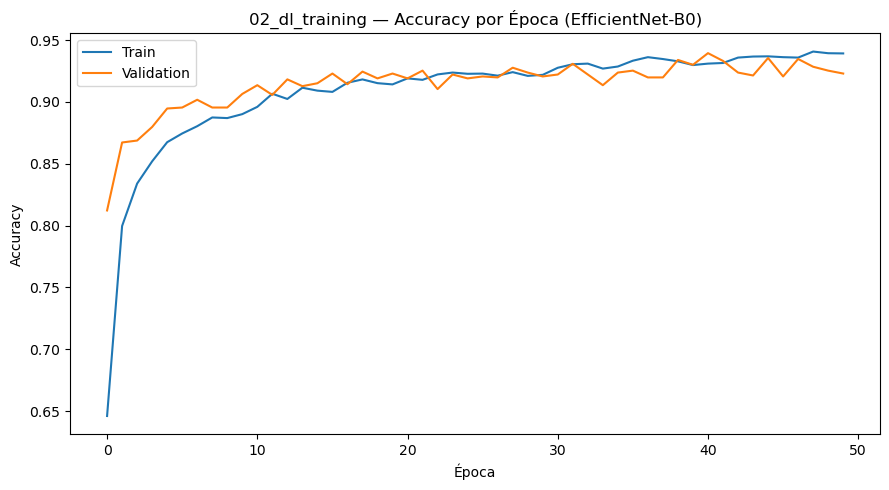

Gráfica guardada: ../outputs/graphics/02_dl_training_accuracy.png


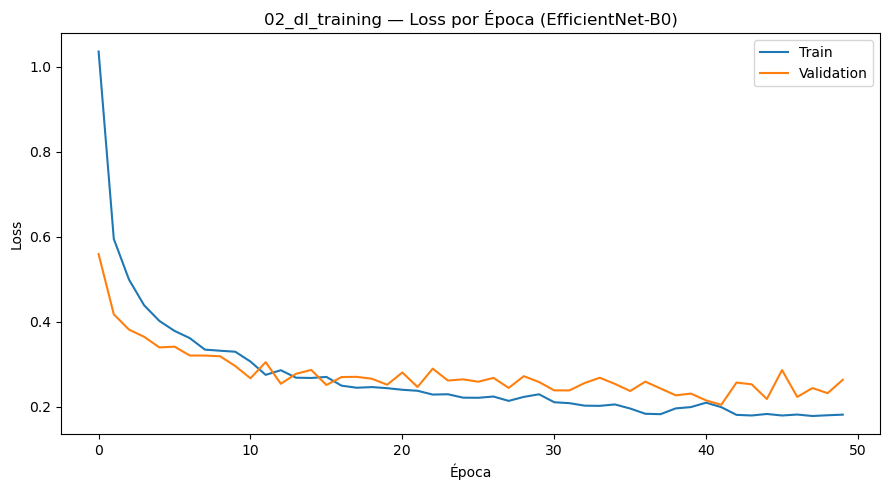

Gráfica guardada: ../outputs/graphics/02_dl_training_loss.png


In [7]:
# 1. GRÁFICAS DE ENTRENAMIENTO

GRAPHICS_DIR = '../outputs/graphics'

# -- Accuracy --
plt.figure(figsize=(9, 5))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('02_dl_training — Accuracy por Época (EfficientNet-B0)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_accuracy.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_accuracy.png')

# -- Loss --
plt.figure(figsize=(9, 5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('02_dl_training — Loss por Época (EfficientNet-B0)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_loss.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_loss.png')

In [8]:
# 2. PREDICCIONES

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
import seaborn as sns
import numpy as np

test_generator.reset()

predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)

y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

40/40 [==============================] - 19s 439ms/step


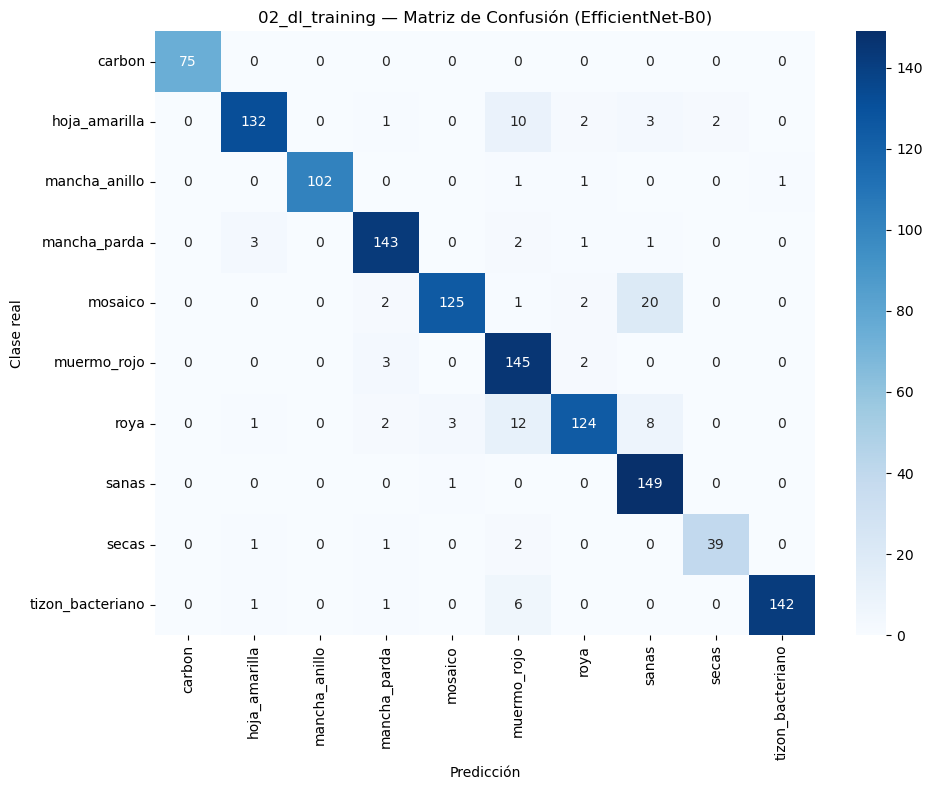

Gráfica guardada: ../outputs/graphics/02_dl_training_confusion_matrix.png


In [9]:
# 3. MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)

plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.title('02_dl_training — Matriz de Confusión (EfficientNet-B0)')
plt.tight_layout()
plt.savefig(f'{GRAPHICS_DIR}/02_dl_training_confusion_matrix.png', dpi=150)
plt.show()
print(f'Gráfica guardada: {GRAPHICS_DIR}/02_dl_training_confusion_matrix.png')


In [10]:
# 4. REPORTE DE CLASIFICACIÓN Y F1 SCORE GLOBAL

print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score Global:", f1)

                  precision    recall  f1-score   support

          carbon       1.00      1.00      1.00        75
   hoja_amarilla       0.96      0.88      0.92       150
   mancha_anillo       1.00      0.97      0.99       105
    mancha_parda       0.93      0.95      0.94       150
         mosaico       0.97      0.83      0.90       150
     muermo_rojo       0.81      0.97      0.88       150
            roya       0.94      0.83      0.88       150
           sanas       0.82      0.99      0.90       150
           secas       0.95      0.91      0.93        43
tizon_bacteriano       0.99      0.95      0.97       150

        accuracy                           0.92      1273
       macro avg       0.94      0.93      0.93      1273
    weighted avg       0.93      0.92      0.92      1273

F1 Score Global: 0.9241721446617911
